In [1]:
!pip install numpy matplotlib scikit-learn torch pandas

In [2]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

# Set random seed and device
RNG = 1337
np.random.seed(RNG)
random.seed(RNG)
torch.manual_seed(RNG)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


In [3]:
#Custom make_moons() Implementation
def make_moons(n_samples=500, noise=0.2, random_state=None):
  if random_state is not None:
    np.random.seed(random_state)
  n1 = n_samples // 2
  n2 = n_samples - n1
  t1 = np.random.rand(n1) * math.pi
  x1 = np.stack([np.cos(t1), np.sin(t1)], axis=1)
  t2 = np.random.rand(n2) * math.pi
  x2 = np.stack([1 - np.cos(t2), -np.sin(t2) + 0.5], axis=1)
  X = np.vstack([x1, x2])
  y = np.hstack([np.zeros(n1, dtype=int), np.ones(n2, dtype=int)])
  X += np.random.normal(scale=noise, size=X.shape)
  perm = np.random.permutation(n_samples)
  return X[perm], y[perm]

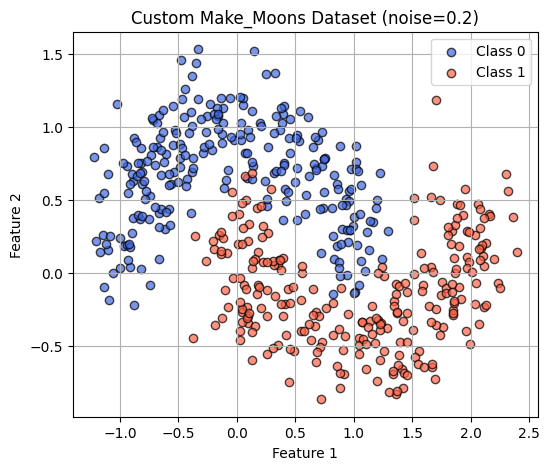

In [18]:
import matplotlib.pyplot as plt

# Generate dataset with default parameters
X, y = make_moons(n_samples=500, noise=0.2, random_state=1337)

# Plot
plt.figure(figsize=(6, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='royalblue', label='Class 0', alpha=0.7, edgecolors='k')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='tomato', label='Class 1', alpha=0.7, edgecolors='k')
plt.title("Custom Make_Moons Dataset (noise=0.2)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()


In [5]:
#Create Datasets (train/test/validation)
X_train_all, y_train_all = make_moons(500, 0.2, RNG)
X_test_20, y_test_20 = make_moons(500, 0.2, RNG+1)
X_test_10, y_test_10 = make_moons(500, 0.1, RNG+2)
X_test_30, y_test_30 = make_moons(500, 0.3, RNG+3)


scaler = StandardScaler()
X_train_all = scaler.fit_transform(X_train_all)
X_test_20 = scaler.transform(X_test_20)
X_test_10 = scaler.transform(X_test_10)
X_test_30 = scaler.transform(X_test_30)


X_train, X_val, y_train, y_val = train_test_split(
  X_train_all, y_train_all, test_size=0.2, random_state=RNG, stratify=y_train_all)

In [6]:
#Helper Functions
def to_tensor(x, y=None):
  xt = torch.tensor(x, dtype=torch.float32).to(device)
  if y is None:
    return xt
  return xt, torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(device)


def count_params(model):
  return sum(p.numel() for p in model.parameters())


def layerwise_sparsity(model, tol=1e-8):
  sparsities = {}
  for name, p in model.named_parameters():
    if 'weight' in name:
      total = p.numel()
      zeros = (p.abs() <= tol).sum().item()
      sparsities[name] = zeros / total
  return sparsities

In [7]:
#Define MLP Model
class MLP(nn.Module):
  def __init__(self, input_dim=2, hidden_sizes=[32, 16], output_dim=1):
    super().__init__()
    layers = []
    last = input_dim
    for h in hidden_sizes:
      layers.append(nn.Linear(last, h))
      layers.append(nn.ReLU())
      last = h
    layers.append(nn.Linear(last, output_dim))
    self.net = nn.Sequential(*layers)


  def forward(self, x):
    return torch.sigmoid(self.net(x))

In [8]:
model = MLP()
print(model)


MLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [9]:
#Training Function (with L1/L2 + Early Stopping)
def train_model(model, Xtr, ytr, Xv, yv, lr=1e-3, epochs=2000, patience=50, l1_lambda=0.0, weight_decay=0.0):
  model = model.to(device)
  optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
  criterion = nn.BCELoss()
  best_val_auc = -np.inf
  best_state = None
  wait = 0


  for ep in range(epochs):
    model.train()
    optimizer.zero_grad()
    out = model(Xtr)
    loss = criterion(out, ytr)
    if l1_lambda > 0:
      l1_norm = sum(p.abs().sum() for name,p in model.named_parameters() if 'weight' in name)
      loss += l1_lambda * l1_norm
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
      probs = model(Xv).cpu().numpy().ravel()
      try:
        val_auc = roc_auc_score(yv.cpu().numpy(), probs)
      except ValueError:
        val_auc = 0.5


    if val_auc > best_val_auc + 1e-8:
      best_val_auc = val_auc
      best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}
      wait = 0
    else:
      wait += 1
    if wait >= patience:
      break
    if best_state is not None:
      model.load_state_dict(best_state)
  return model, best_val_auc

In [10]:
#Evaluation Helper
def evaluate_model(model, X, y_true, poly=None):
  if poly:
    X = poly.transform(X)
  if isinstance(model, nn.Module):
    model.eval()
    with torch.no_grad():
      probs = model(torch.tensor(X, dtype=torch.float32).to(device)).cpu().numpy().ravel()
  else:
    probs = model.predict_proba(X)[:,1]
  preds = (probs>=0.5).astype(int)
  return accuracy_score(y_true, preds), roc_auc_score(y_true, probs)

In [11]:
#Train All Models
X_train_t, y_train_t = to_tensor(X_train, y_train)
X_val_t, y_val_t = to_tensor(X_val, y_val)


# MLP with early stopping
mlp1 = MLP()
mlp1, _ = train_model(mlp1, X_train_t, y_train_t, X_val_t, y_val_t, patience=50)


# MLP with L1 regularization grid
l1_grid = [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4]
l1_results = []
for lam in l1_grid:
  m = MLP()
  m, val_auc = train_model(m, X_train_t, y_train_t, X_val_t, y_val_t, l1_lambda=lam)
  l1_results.append({'lambda':lam,'val_auc':val_auc,'sparsity':layerwise_sparsity(m),'params':count_params(m)})
# MLP with L2 regularization grid
l2_grid = [0.0, 1e-6, 3e-6, 1e-5, 3e-5, 1e-4]
l2_results = []
for wd in l2_grid:
  m = MLP()
  m, val_auc = train_model(m, X_train_t, y_train_t, X_val_t, y_val_t, weight_decay=wd)
  l2_results.append({'weight_decay':wd,'val_auc':val_auc,'params':count_params(m)})


# Logistic Regression with polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
Xtrain_poly = poly.fit_transform(X_train)
logreg = LogisticRegression(max_iter=5000)
logreg.fit(Xtrain_poly, y_train)

LogisticRegression(max_iter=5000)

In [12]:
#Evaluate Models and Create Summary
# Evaluate all four models on test noise = 0.1, 0.2, 0.3
acc1_20, auc1_20 = evaluate_model(mlp1, X_test_20, y_test_20)
acc1_10, auc1_10 = evaluate_model(mlp1, X_test_10, y_test_10)
acc1_30, auc1_30 = evaluate_model(mlp1, X_test_30, y_test_30)


best_l1 = max(l1_results, key=lambda r:r['val_auc'])
mlp2 = MLP()
mlp2, _ = train_model(mlp2, X_train_t, y_train_t, X_val_t, y_val_t, l1_lambda=best_l1['lambda'])
acc2_20, auc2_20 = evaluate_model(mlp2, X_test_20, y_test_20)
acc2_10, auc2_10 = evaluate_model(mlp2, X_test_10, y_test_10)
acc2_30, auc2_30 = evaluate_model(mlp2, X_test_30, y_test_30)

best_l2 = max(l2_results, key=lambda r:r['val_auc'])
mlp3 = MLP()
mlp3, _ = train_model(mlp3, X_train_t, y_train_t, X_val_t, y_val_t, weight_decay=best_l2['weight_decay'])
acc3_20, auc3_20 = evaluate_model(mlp3, X_test_20, y_test_20)
acc3_10, auc3_10 = evaluate_model(mlp3, X_test_10, y_test_10)
acc3_30, auc3_30 = evaluate_model(mlp3, X_test_30, y_test_30)


poly_train = poly.fit_transform(X_train)
logreg.fit(poly_train, y_train)
acc4_20, auc4_20 = evaluate_model(logreg, X_test_20, y_test_20, poly)
acc4_10, auc4_10 = evaluate_model(logreg, X_test_10, y_test_10, poly)
acc4_30, auc4_30 = evaluate_model(logreg, X_test_30, y_test_30, poly)

summary = pd.DataFrame([
{'model':'MLP_EarlyStop','params':count_params(mlp1),'acc_0.1':acc1_10,'acc_0.2':acc1_20,'acc_0.3':acc1_30,'auc_0.2':auc1_20},
{'model':'MLP_L1','params':count_params(mlp2),'acc_0.1':acc2_10,'acc_0.2':acc2_20,'acc_0.3':acc2_30,'auc_0.2':auc2_20},
{'model':'MLP_L2','params':count_params(mlp3),'acc_0.1':acc3_10,'acc_0.2':acc3_20,'acc_0.3':acc3_30,'auc_0.2':auc3_20},
{'model':'Logistic_Poly','params':logreg.coef_.size+1,'acc_0.1':acc4_10,'acc_0.2':acc4_20,'acc_0.3':acc4_30,'auc_0.2':auc4_20},
])
summary

,model,params,acc_0.1,acc_0.2,acc_0.3,auc_0.2
0,MLP_EarlyStop,641,0.900,0.868,0.826,0.945552
1,MLP_L1,641,0.840,0.838,0.800,0.933392
2,MLP_L2,641,0.848,0.832,0.836,0.939216
3,Logistic_Poly,6,0.894,0.870,0.856,0.947264


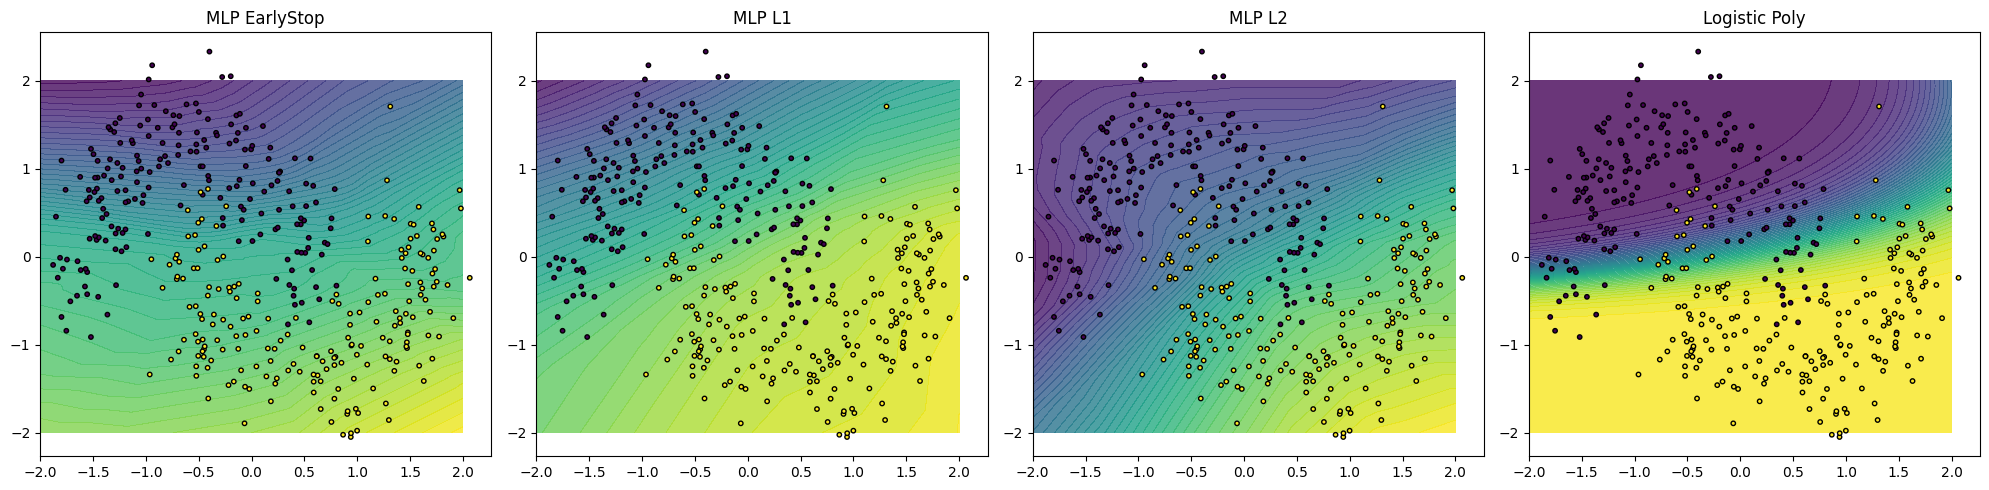

In [13]:
#Plot Decision Boundaries
def plot_decision_boundary(model, title, model_type='torch'):
  xx, yy = np.meshgrid(np.linspace(-2,2,400), np.linspace(-2,2,400))
  grid = np.c_[xx.ravel(), yy.ravel()]
  grid_std = scaler.transform(grid)
  if model_type=='torch':
    with torch.no_grad():
      Z = model(torch.tensor(grid_std, dtype=torch.float32).to(device)).cpu().numpy().ravel()
  else:
    Z = model.predict_proba(poly.transform(grid_std))[:,1]
  Z = Z.reshape(xx.shape)
  plt.contourf(xx, yy, Z, levels=50, alpha=0.8)
  plt.scatter(X_train[:,0], X_train[:,1], c=y_train, s=10, edgecolor='k')
  plt.title(title)


plt.figure(figsize=(20,5))
plt.subplot(1,4,1); plot_decision_boundary(mlp1,'MLP EarlyStop')
plt.subplot(1,4,2); plot_decision_boundary(mlp2,'MLP L1')
plt.subplot(1,4,3); plot_decision_boundary(mlp3,'MLP L2')
plt.subplot(1,4,4); plot_decision_boundary(logreg,'Logistic Poly','sklearn')
plt.tight_layout(); plt.show()

Effect of L1 on sparsity and boundary jaggedness:
high sparsity and more jaggedness can be seen.

Effect of L2 on smoothness and margin:
Low sparsity and smooth, continuous boundary.

In [14]:
#Class Imbalance Experiment
def create_imbalanced_train(X, y, ratio=0.7, random_state=None):
  if random_state: np.random.seed(random_state)
  n = len(y)
  n0 = int(n*ratio); n1 = n-n0
  idx0, idx1 = np.where(y==0)[0], np.where(y==1)[0]
  sel0 = np.random.choice(idx0, n0, replace=True)
  sel1 = np.random.choice(idx1, n1, replace=True)
  sel = np.hstack([sel0, sel1])
  np.random.shuffle(sel)
  return X[sel], y[sel]


X_imb, y_imb = create_imbalanced_train(X_train_all, y_train_all, ratio=0.7, random_state=RNG)
X_imb_t, y_imb_t = to_tensor(X_imb, y_imb)
mlp_imb = MLP()
mlp_imb, _ = train_model(mlp_imb, X_imb_t, y_imb_t, X_val_t, y_val_t, patience=50)
acc_imb, auc_imb = evaluate_model(mlp_imb, X_test_20, y_test_20)
print(f'Imbalanced (70:30) → Test Acc: {acc_imb:.3f}, AUROC: {auc_imb:.3f}')

Imbalanced (70:30) → Test Acc: 0.730, AUROC: 0.923


In [15]:
#Save Results
summary.to_csv('summary_results.csv', index=False)
pd.DataFrame(l1_results).to_csv('l1_results.csv', index=False)
pd.DataFrame(l2_results).to_csv('l2_results.csv', index=False)
print('Saved CSV results to working directory.')

Saved CSV results to working directory.
